In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
class MoDiff:
    def __init__(self, data: pd.Series, col: str):
        self.data = data
        self.std = None
        self.th = None
        self.col = col
        self.labels_df = None


    def train(self, fecha, num: int):
        fecha = pd.to_datetime(fecha)

        data_test = self.data.loc[:fecha]

        n = len(data_test)

        diff_centrada = []

        for i in range(n):
            if i != 0 and i != n-1:
                dato = data_test.iloc[i]
                if not np.isnan(dato):

                    if i-1 >= 0 and not np.isnan(data_test.iloc[i - 1]):
                        dato_anterior = data_test.iloc[i - 1]
                    elif i-2 >= 0 and not np.isnan(data_test.iloc[i - 2]):
                        dato_anterior = data_test.iloc[i - 2]
                    else:
                        continue

                    if i-1 < n and not np.isnan(data_test.iloc[i + 1]):
                        dato_siguiente = data_test.iloc[i + 1]
                    elif i-2 < n and not np.isnan(data_test.iloc[i + 2]):
                        dato_siguiente = data_test.iloc[i + 2]
                    else:
                        continue
                    
                    diff_anterior = abs(dato - dato_anterior)
                    diff_siguiente = abs(dato - dato_siguiente)


                    diff_centrada.append(min(diff_anterior, diff_siguiente))

        self.std = np.std(diff_centrada, ddof=1)
        self.th = self.std * num
        return diff_centrada

    def plot_train(self):
        pass

    def pred(self, data, indice: int):
        if indice == -1:
            pass
        pass

    def etiquetar_data(self):
        n = len(self.data)

        indx = self.data.index
        valores = self.data.values
        diff_anterior_l = np.full(n, np.nan, dtype=float)
        diff_siguiente_l = np.full(n, np.nan, dtype=float)
        labels   = np.full(n, pd.NA, dtype="object") 

        for i in range(n):
            dato = valores[i]

            if i == 0 or i == n-1:
                continue

            if np.isnan(dato):
                continue

            diff_anterior = np.nan

            if i-1 >= 0 and not np.isnan(valores[i-1]):
                diff_anterior = abs(dato - valores[i-1])
            elif i-2 >= 0 and not np.isnan(valores[i-2]):
                diff_anterior = abs(dato - valores[i-2])

            diff_siguiente = np.nan

            if i-1 < n and not np.isnan(valores[i+1]):
                diff_siguiente = abs(dato - valores[i+1])
            elif i-2 < n and not np.isnan(valores[i+2]):
                diff_siguiente = abs(dato - valores[i+2])
            
            diff_anterior_l[i] = diff_anterior
            diff_siguiente_l[i] = diff_siguiente


            if not np.isnan(diff_anterior) and not np.isnan(diff_siguiente):
                labels[i] = int((diff_anterior >= self.th) and (diff_siguiente >= self.th))
            else:
                labels[i] = pd.NA

        labels = pd.Series(labels, index=indx, dtype="Int64")

        self.labels_df = pd.DataFrame({
            "valores": self.data,
            "diff_prev": pd.Series(diff_anterior_l, index=indx),
            "diff_next": pd.Series(diff_siguiente_l, index=indx),
            "label": labels
        })



In [2]:
df = pd.read_csv('../df_procesados/df_planta_1.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

In [4]:
df.columns

Index(['date_time', 'Conductividad DAF',
       'Flujo Parshall 01 entrada a Ecualizador 1', 'Flujo de envío a DAF',
       'Nivel Ecualizador 1 (Tk 30m3)', 'Nivel Ecualizador 2 (Tk 250m3)',
       'Temperatura DAF', 'pH Clarificado DAF (Tk 80m3)',
       'pH Ecualizador 2 (Tk 250m3)', 'pH coagulación entrada DAF',
       'pH entrada a Ecualizador 2 (Tk 250m3)', 'pH salida a Parshall 02',
       'Nivel Clarificado DAF (Tk 80m3)', 'pH entrada a Ecualizador 1',
       'Turbidez salida DAF', 'pH salida y control Ecualizador 1',
       'planta1_activa'],
      dtype='object')

In [5]:
df.columns[9]

'pH coagulación entrada DAF'

In [6]:
columna = df.columns[9]

s = df.set_index('date_time')[columna]

mo = MoDiff(s, col = columna)

res = mo.train("2025-06-15", num=6)

mo.etiquetar_data()

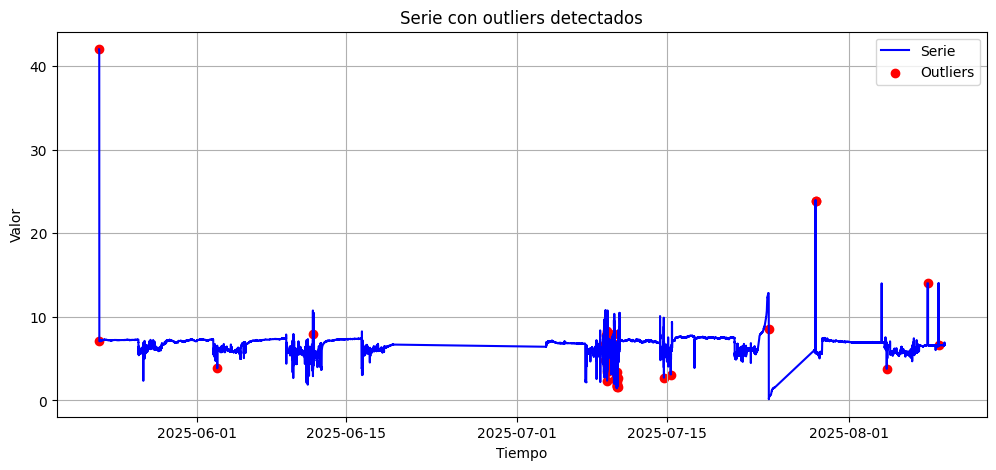

In [7]:
df_labels = mo.labels_df

plt.figure(figsize=(12,5))
plt.plot(df_labels.index, df_labels["valores"], label="Serie", color="blue")

# marcar outliers
mask_out = df_labels["label"] == 1
plt.scatter(
    df_labels.index[mask_out],
    df_labels["valores"][mask_out],
    color="red", marker="o", label="Outliers"
)

plt.title("Serie con outliers detectados")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()